# Scores for the Classifier Free Guided Flow Matching Models

In [1]:
import json

import matplotlib.pyplot as plt
import polars as pl
import seaborn as sns

import wandb
from genpp.plots import RESULTS_DIR
import matplotlib.colors as mcolors
from itertools import chain

In [2]:
api = wandb.Api()

# Get runs with a specific tag
runs = api.runs(
    "feik/genpp",  # Replace with your entity/project
    filters={"tags": {"$all": ["final", "wb2", "cfg"], "$nin": ["deprecated"]}},
)

baseline = api.runs(
    "feik/genpp",  # Replace with your entity/project
    filters={"tags": {"$all": ["final", "wb2", "baseline"], "$nin": ["deprecated"]}},
)

for run in chain(baseline, runs):
    print(run.tags, run.url)

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /home/feik/.netrc.


['baseline', 'best', 'final', 'wb2'] https://wandb.ai/feik/genpp/runs/utgo5npv
['cfg', 'extra', 'final', 'fm_uvit_cfg', 'indirect', 'wb2'] https://wandb.ai/feik/genpp/runs/8uzxz34p
['cfg', 'direct', 'extra', 'final', 'fm_uvit_cfg', 'wb2'] https://wandb.ai/feik/genpp/runs/wt5vwm2n


In [3]:
rows = []

for run in runs:
    run_id = run.id
    summary = run.summary._json_dict
    summary_cut = {k: v for k, v in summary.items() if k.startswith("guidance_")}

    tags = run.tags
    if "direct" in tags:
        pred_method = "direct"
    elif "indirect" in tags:
        pred_method = "indirect"
    else:
        pred_method = None

    json_config = json.loads(run.json_config)
    model_name = json_config["name"]["value"]

    for guidance, splits in summary_cut.items():
        for split, metrics in splits.items():
            for metric, horizons in metrics.items():
                for horizon, value in horizons.items():
                    rows.append(
                        {
                            "model_name": model_name,
                            "Predict Type": pred_method,
                            "guidance": guidance,
                            "split": split,
                            "metric": metric,
                            "horizon": horizon,
                            "value": value,
                        }
                    )

baseline_rows = []
for run in baseline:
    run_id = run.id

    json_config = json.loads(run.json_config)
    model_name = json_config["name"]["value"]
    summary = {
        key: value
        for key, value in run.summary._json_dict.items()
        if key in ["train", "val", "test"]
    }

    for split, metrics in summary.items():
        for metric, horizons in metrics.items():
            for horizon, value in horizons.items():
                baseline_rows.append(
                    {
                        "model_name": model_name,
                        "split": split,
                        "metric": metric,
                        "horizon": horizon,
                        "value": value,
                    }
                )

df = pl.DataFrame(rows)
df = df.with_columns(
    pl.col("guidance").str.replace("guidance_", "").cast(pl.Categorical).alias("Guidance"),
    pl.col("horizon").alias("horizon_str"),
    pl.col("horizon").str.replace("h", "").cast(pl.Int32).alias("horizon"),
    pl.col("metric")
    .str.split("_")
    .list.first()
    .replace({"EnergyScore": "Energy Score", "VariogramScore": "Variogram Score"})
    .alias("score"),
    pl.col("metric").str.split("_").list.slice(1).list.join("_").alias("variable"),
    pl.col("horizon")
    .str.replace("h", "")
    .cast(pl.Float64)
    .mul(1 / 24)
    .cast(pl.Int32)
    .alias("Lead Time (d)"),
)

baseline_df = pl.DataFrame(baseline_rows)
baseline_df = baseline_df.with_columns(
    pl.col("horizon").alias("horizon_str"),
    pl.col("horizon").str.replace("h", "").cast(pl.Int32).alias("horizon"),
    pl.col("metric")
    .str.split("_")
    .list.first()
    .replace({"EnergyScore": "Energy Score", "VariogramScore": "Variogram Score"})
    .alias("score"),
    pl.col("metric").str.split("_").list.slice(1).list.join("_").alias("variable"),
)

In [4]:
df = (
    df.join(
        # Get the RAW values for each combination
        baseline_df.select(["split", "horizon", "metric", "value"]).rename({"value": "raw_value"}),
        on=["split", "horizon", "metric"],
        how="left",
    )
    .with_columns(
        # Calculate the skill score
        ((pl.col("raw_value") - pl.col("value")) / (pl.col("raw_value") - pl.lit(0.000))).alias(
            "Skill Score"
        )
    )
    .drop("raw_value")
)

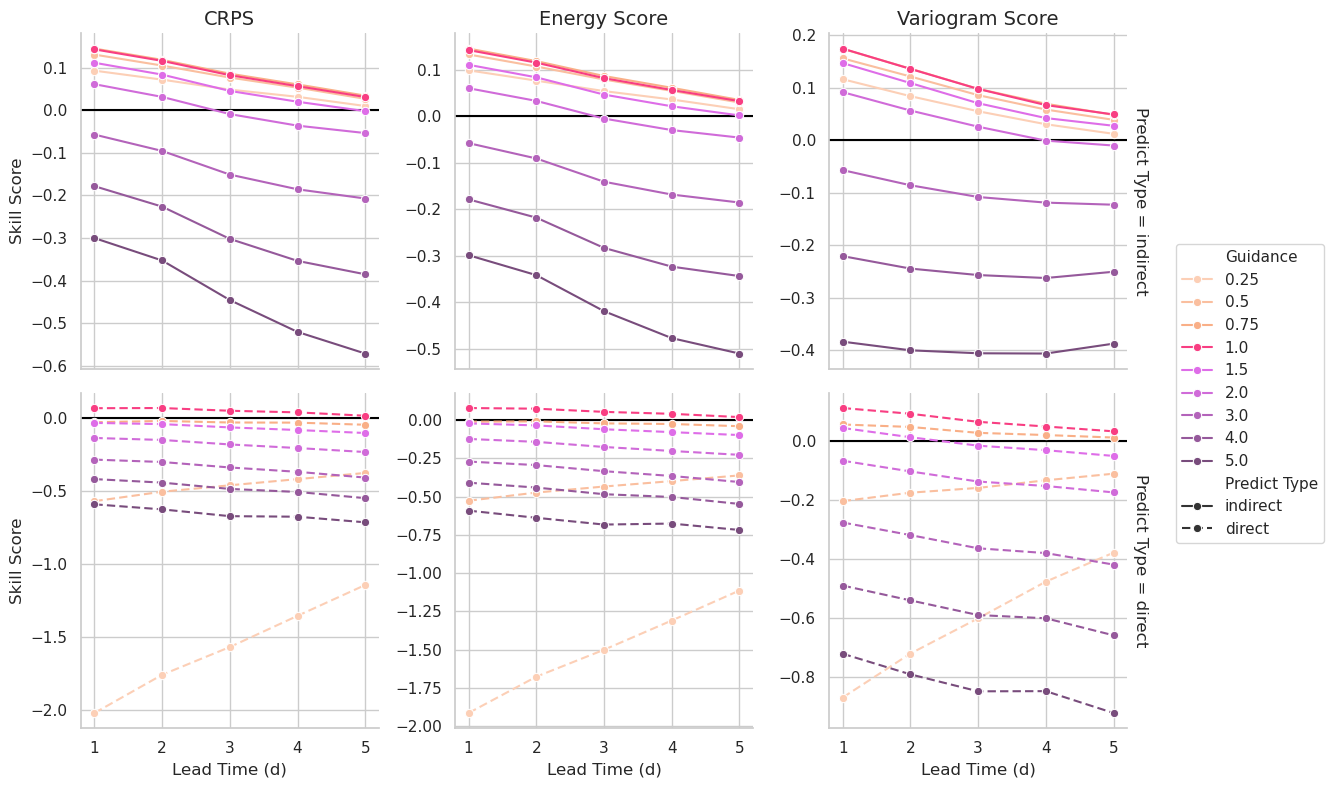

In [5]:
sns.set_theme(style="whitegrid")

base_color = "#F83E82"


def make_guidance_palette(guidance_values, base_hex, desat=0.5, hue_shift=0.12):
    """Create a palette with a gradient that highlights 1.0.

    - 1.0 keeps the full vivid base color.
    - Values < 1.0 are shifted toward blue (cooler) and desaturated, with a
      lightness gradient (further from 1.0 = lighter/more faded).
    - Values > 1.0 are shifted toward orange (warmer) and desaturated, with a
      darkness gradient (further from 1.0 = darker).
    """
    import colorsys

    base_rgb = mcolors.to_rgb(base_hex)
    base_h, base_s, base_v = colorsys.rgb_to_hsv(*base_rgb)
    sorted_vals = sorted(set(guidance_values), key=float)
    palette = {}

    float_vals = [float(v) for v in sorted_vals if float(v) != 1.0]
    below = [v for v in float_vals if v < 1.0]
    above = [v for v in float_vals if v > 1.0]
    min_g = min(below) if below else 0.0
    max_g = max(above) if above else 2.0

    for g in sorted_vals:
        g_float = float(g)
        if g_float == 1.0:
            palette[g] = base_hex
        elif g_float < 1.0:
            # Shift hue toward blue, desaturate, lighten with gradient
            t = (g_float - min_g) / (1.0 - min_g) if min_g < 1.0 else 0.5
            h = (base_h + hue_shift) % 1.0  # shift toward blue/purple
            s = max(base_s - desat, 0.0) * (0.5 + 0.5 * t)
            v = min(base_v + (1.0 - base_v) * 0.5 * (1.0 - t), 1.0)
            rgb = colorsys.hsv_to_rgb(h, s, v)
            palette[g] = mcolors.to_hex(rgb)
        else:
            # Shift hue toward orange, desaturate, darken with gradient
            t = (g_float - 1.0) / (max_g - 1.0) if max_g > 1.0 else 0.5
            h = (base_h - hue_shift) % 1.0  # shift toward orange/warm
            s = max(base_s - desat, 0.0) * (1.0 - 0.3 * t)
            v = base_v * (1.0 - 0.5 * t)
            rgb = colorsys.hsv_to_rgb(h, s, v)
            palette[g] = mcolors.to_hex(rgb)
    return palette


df_filter = df.filter(pl.col("variable").eq("combined"))
guidance_values = df_filter["Guidance"].unique().to_list()
guidance_palette = make_guidance_palette(guidance_values, base_hex=base_color, desat=0.2)

g = sns.FacetGrid(
    df_filter.to_pandas(),
    col="score",
    row="Predict Type",
    height=4,
    aspect=1,
    sharex=True,
    sharey=False,
    margin_titles=True,
)

g.map_dataframe(
    sns.lineplot,
    x="Lead Time (d)",
    y="Skill Score",
    hue="Guidance",
    palette=guidance_palette,
    style="Predict Type",
    style_order=["indirect", "direct"],
    dashes={"indirect": "", "direct": (4, 2)},
    linewidth=1.5,
    legend=True,
    marker="o",
)

for ax in g.axes.flat:
    ax.axhline(0, color="black", linewidth=1.5, zorder=1)
    # ax.ticklabel_format(style="scientific", axis="y", scilimits=(0, 0))
    ax.set_xlabel("Lead Time (d)", fontsize=12)
    ax.set_title(ax.get_title().replace("score = ", ""), fontsize=14)
    if ax.get_ylabel() != "":
        ax.set_ylabel("Skill Score", fontsize=12)

g.add_legend(frameon=True)
# g.figure.tight_layout()
g.figure.savefig(
    RESULTS_DIR / "results" / "wb2" / "ablations" / "guidance_leadtime_skill.pdf",
    bbox_inches="tight",
)

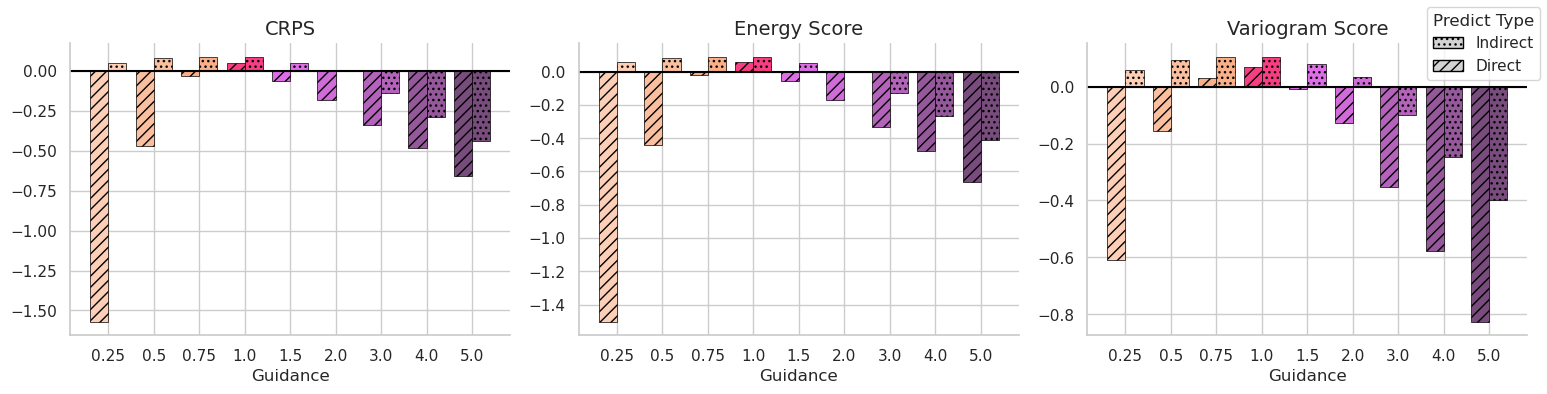

In [6]:
from matplotlib.patches import Patch

hatch_map = {"indirect": "...", "direct": "///"}

g = sns.FacetGrid(
    df_filter.to_pandas(),
    col="score",
    height=4,
    aspect=1.2,
    sharex=True,
    sharey=False,
    margin_titles=True,
)


def barplot_with_hatch(data, **kwargs):
    ax = plt.gca()
    guidance_vals = sorted(data["Guidance"].unique(), key=float)
    pred_methods = sorted(data["Predict Type"].dropna().unique())
    n_methods = max(len(pred_methods), 1)
    bar_width = 0.8 / n_methods

    for j, pm in enumerate(pred_methods):
        pm_data = data[data["Predict Type"] == pm]
        for i, gv in enumerate(guidance_vals):
            gv_data = pm_data[pm_data["Guidance"] == gv]
            if len(gv_data) > 0:
                offset = (j - (n_methods - 1) / 2) * bar_width
                ax.bar(
                    i + offset,
                    gv_data["Skill Score"].mean(),
                    bar_width,
                    color=guidance_palette.get(gv, "gray"),
                    hatch=hatch_map.get(pm, ""),
                    edgecolor="black",
                    linewidth=0.5,
                )
    ax.set_xticks(range(len(guidance_vals)))
    ax.set_xticklabels(guidance_vals)


g.map_dataframe(barplot_with_hatch)

for ax in g.axes.flat:
    ax.axhline(0, color="black", linewidth=1.5, zorder=1)
    # ax.ticklabel_format(style="scientific", axis="y", scilimits=(0, 0))
    ax.set_xlabel("Guidance", fontsize=12)
    ax.set_title(ax.get_title().replace("score = ", ""), fontsize=14)
    if ax.get_ylabel() != "":
        ax.set_ylabel("Skill Score", fontsize=12)

legend_elements = [
    Patch(facecolor="lightgray", edgecolor="black", hatch="...", label="Indirect"),
    Patch(facecolor="lightgray", edgecolor="black", hatch="///", label="Direct"),
]
g.add_legend(
    handles=legend_elements,  # type: ignore
    title="Predict Type",
    loc="upper right",
    frameon=True,
)
g.figure.tight_layout()
g.figure.savefig(
    RESULTS_DIR / "results" / "wb2" / "ablations" / "guidance_skill_bar.pdf",
    bbox_inches="tight",
)

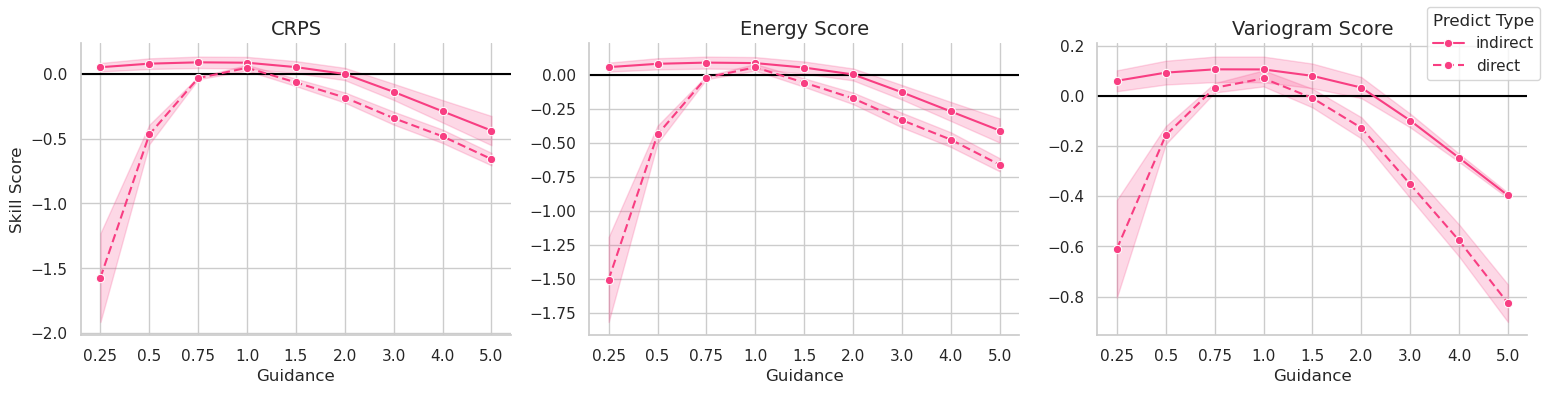

In [7]:
g = sns.FacetGrid(
    df_filter.to_pandas(),
    col="score",
    height=4,
    aspect=1.2,
    sharex=True,
    sharey=False,
    margin_titles=True,
)
g.map_dataframe(
    sns.lineplot,
    x="Guidance",
    y="Skill Score",
    color=base_color,
    style="Predict Type",
    style_order=["indirect", "direct"],
    dashes={"indirect": "", "direct": (4, 2)},
    legend=True,
    errorbar="sd",
    marker="o",
)

for ax in g.axes.flat:
    ax.axhline(0, color="black", linewidth=1.5, zorder=1)
    # ax.ticklabel_format(style="scientific", axis="y", scilimits=(0, 0))
    ax.set_xlabel("Guidance", fontsize=12)
    ax.set_title(ax.get_title().replace("score = ", ""), fontsize=14)
    if ax.get_ylabel() != "":
        ax.set_ylabel("Skill Score", fontsize=12)

g.add_legend(frameon=True, title="Predict Type", loc="upper right")
g.figure.tight_layout()
g.figure.savefig(
    RESULTS_DIR / "results" / "wb2" / "ablations" / "guidance_skill.pdf",
    bbox_inches="tight",
)